In [ ]:
import matplotlib.pyplot as plt
import sys
import numpy as np

sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
from CNMF.traces import ridge_plot, get_traces,normalize_eventtimes
from rois.rois import remove_bad_cells
from matplotlib import rcParams
rcParams['font.family']='Galvji'
rcParams['svg.fonttype']='none'

In [2]:
ani,fov='989N','FOV1'
file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
base_dir = '/Volumes/AM_SSD1/Spont2P'
dff, ev, etimes, est = get_traces(ani, fov, 'Post', file_key,base_dir)

deconvolution file: /Volumes/AM_SSD1/Spont2P/deconvolution/deconvolution_results/deconv_results_min5/989N_TSeries-05202022-012_cnmfresults_5252022_12238_dff_l0deconv.pkl


In [3]:
good = remove_bad_cells(ani,fov,file_key,base_dir,snr_thr=4.0)
pre = good.Baseline.loc[good.Baseline!=-1].values


/Volumes/AM_SSD1/Spont2P/Tagging/989N_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Spont2P/CellReg/989N_FOV1/cellRegistered_20220613_225153.mat


378 Cells detected in registration
260 Cells detected in session 1 of 2
253 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
381 cells filtered to 355cells
131 registered cells
117 baseline only cells
107 post only cells


In [19]:
inds = np.random.choice(pre,10,replace=False)

In [20]:
inds

array([186, 137,  31,  19, 131,  71, 226,  50,  35, 238])

In [5]:
inds=[108, 137,  25,  94,   8,  77, 203,  59, 185, 166]

In [52]:
from scipy.stats import zscore

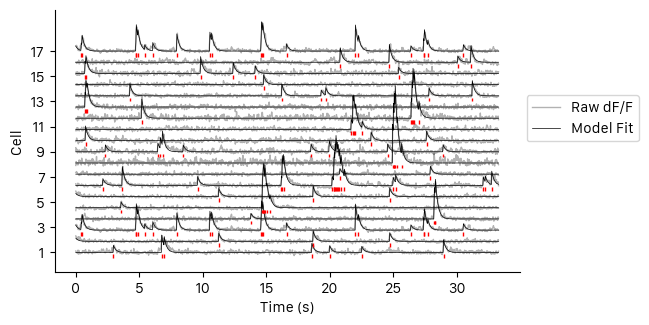

In [104]:
t0,t1=15000,16000
times = np.arange(0,t1-t0)/30
ii = [137,203,94,101,93,203,185,25,54,35,4,45,36,17,28,40,62,73,94]
events = [normalize_eventtimes(etimes[i],t0,t1) for i in ii]


fig,ax=plt.subplots(figsize=(6,3.4))
ridge_plot(dff[ii,t0:t1],times,overlay=est[ii,t0:t1],trace_spacing=1.5,ytick_spacing=2,title=None,color='black',text_color = None,
               alpha=.3,line_width=1,ax = ax,legend=True,eventtimes=events,eventoffset=3,event_linewidth=1,event_color='r')
plt.xlabel('Time (s)')
plt.ylabel('Cell')
plt.legend(bbox_to_anchor=(1,.7))
plt.savefig('deconv_traces_example.svg',transparent=True)

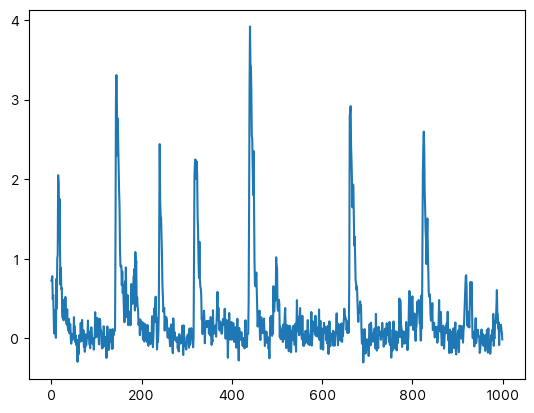

In [105]:
plt.plot(dff[94,15000:16000])

<AxesSubplot: >

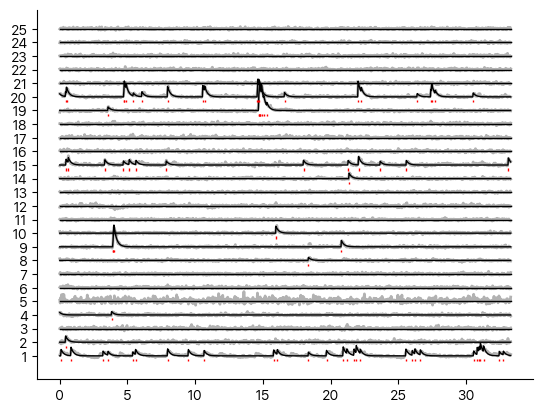

In [88]:
t0,t1=15000,16000
times = np.arange(0,t1-t0)/30
ii = [137,203,94,185,101,203,185,25,35,3]
ii=np.arange(75,100)
events = [normalize_eventtimes(etimes[i],t0,t1) for i in ii]

ridge_plot(dff[ii,t0:t1],times,overlay=est[ii,t0:t1],trace_spacing=3,ytick_spacing=1,title=None,color='black',text_color = None,
               alpha=.3,line_width=2,legend=True,eventtimes=events,eventoffset=3,event_linewidth=1,event_color='r')